## This is a sample Machine Learning project that exemplifies how to proceed Hierarchical Multilevel Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM #estimação
from statstests.process import stepwise
from scipy import stats
from scipy.stats import gaussian_kde
import time
import imageio
from IPython.display import Image, display
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Performance = f(study_hours, professor_experience_years). Hierarchical Linear Models (HLM) or Generalized Linear Mixed Models (GLMM). Multilevel (Nested) Regression Analysis.

This is a simple use-case for Generalized Linear Mixed Models (GLMM) of type Hierarchical Linear Model with 2 levels (HLM2): student (level 1) and school (level 2). In this type of model, we have 2 levels (or layers) of contextual units, each with their respective regression analysis - one nested inside the other, including level-exclusive predictors and coefficient params. In this use-case, for level 1, the level whose predictors only depend on students and not on specific schools, we have the predictive variable study_hours, which is the study hours/week each student (observation) has. For level 2, the level whose predictors depend on schools, we have the predictive variable professor_experience_years, which has the same value for each particular school and for all students nested inside it. So, we have observations (students) nested inside different level-2 contexts (schools), and the dependent variable - performance (of the student) - regress on predictors at two different levels, being level 1 (student layer) nested inside level 2 (school layer). Each school is a different context (or level unit) for a specific group of students (observations). Not only the level-2 predictors' values will change according to the context (school) each observation (student) belongs to, while interacting with the level-1 predictors as well, but we'll also have random effects, at level 2, for both the intercept and slope betas from level 1 when regressed at level 2. The final expression of the multi-level regression model of this example will thus contain all params from level 2 substituted at level 1 traditional regression expression, so that each prediction will take into account all levels regressors and params (including random effect params). For more, see explanations and formulas down below. For other n-level HLM, see other examples at this same project directory.

![./glmm-hlm.png](./glmm-hlm.png)

In [2]:
student_school_df = pd.read_csv('student-school-performance.csv', delimiter=',')
student_school_df

,student,school,performance,study_hours,professor_experience_years
0,1,1,25.0,11,3.6
1,2,1,52.0,23,3.6
2,3,1,52.0,25,3.6
3,4,1,30.0,14,3.6
4,5,1,51.0,24,3.6
...,...,...,...,...,...
353,354,10,46.5,28,3.9
354,355,10,21.0,9,3.9
355,356,10,42.0,27,3.9
356,357,10,14.0,7,3.9


In [3]:
student_school_df['student'] = student_school_df['student'].astype('category')
student_school_df['school'] = student_school_df['school'].astype('category')
student_school_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   student                     358 non-null    category
 1   school                      358 non-null    category
 2   performance                 358 non-null    float64 
 3   study_hours                 358 non-null    int64   
 4   professor_experience_years  358 non-null    float64 
dtypes: category(2), float64(2), int64(1)
memory usage: 12.4 KB


In [4]:
student_school_df.describe()

,performance,study_hours,professor_experience_years
count,358.000000,358.000000,358.000000
mean,41.554190,18.997207,5.161173
std,23.225896,6.368910,3.682676
min,6.500000,4.000000,1.900000
25%,21.000000,14.000000,1.900000
50%,35.500000,20.000000,3.600000
75%,59.000000,24.000000,7.500000
max,100.000000,31.000000,13.000000


In [5]:
student_school_df.groupby('school')['student'].count().reset_index()

,school,student
0,1,47
1,2,25
2,3,48
3,4,20
4,5,48
5,6,30
6,7,28
7,8,35
8,9,44
9,10,33


In [6]:
avg_performance = student_school_df.groupby('school')['performance'].mean().reset_index()
avg_performance

,school,performance
0,1,36.765957
1,2,21.400000
2,3,67.125000
3,4,55.325000
4,5,19.270833
5,6,33.966667
6,7,57.532143
7,8,75.428571
8,9,18.556818
9,10,38.590909


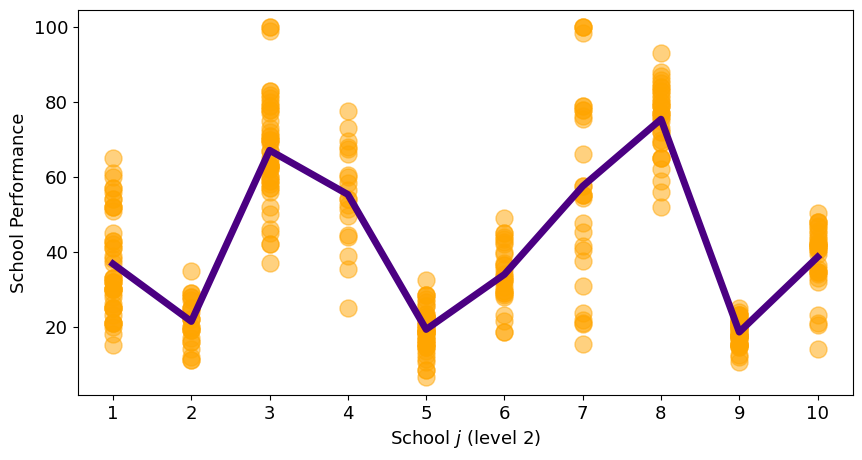

In [7]:
# Students' average performance graph - per school

plt.figure(figsize=(10,5))
plt.plot(avg_performance['school'], avg_performance['performance'],
         linewidth=5, color='indigo')
plt.scatter(student_school_df['school'], student_school_df['performance'],
            alpha=0.5, color='orange', s = 150)
plt.xlabel('School $j$ (level 2)', fontsize=13)
plt.ylabel('School Performance', fontsize=13)
plt.xticks(avg_performance.school, fontsize=13)
plt.yticks(fontsize=13)
plt.show()

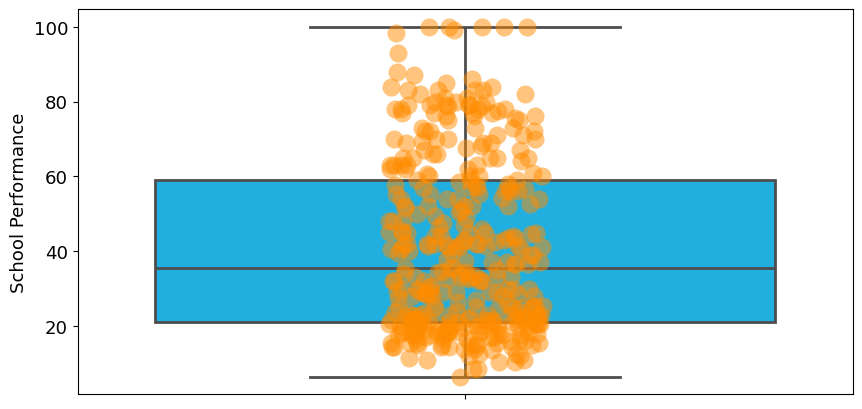

In [8]:
# Students' average performance graph - boxplot

plt.figure(figsize=(10,5))
sns.boxplot(data=student_school_df, y='performance',
            linewidth=2, orient='v', color='deepskyblue')
sns.stripplot(data=student_school_df, y='performance',
              color='darkorange', jitter=0.1, size=13, alpha=0.5)
plt.ylabel('School Performance', fontsize=13)
plt.yticks(fontsize=13)
plt.show()

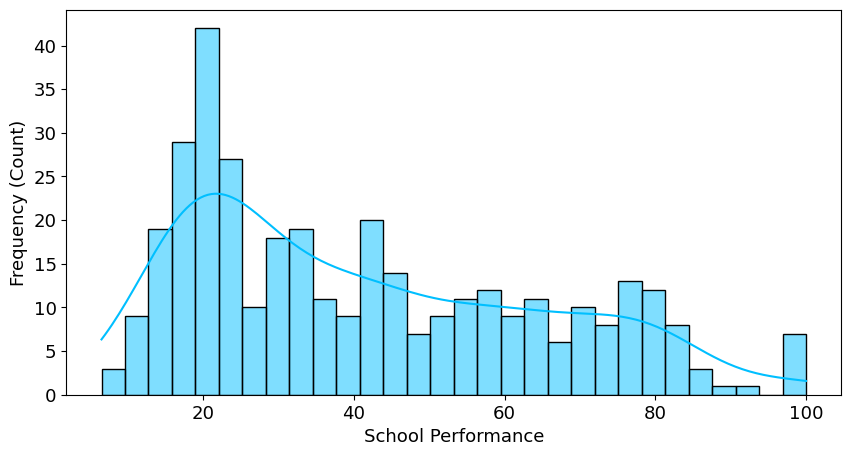

In [9]:
# KDE (probability density function PDF estimate) graph of dependent variable ('performance')

plt.figure(figsize=(10,5))
sns.histplot(data=student_school_df['performance'], kde=True,
             bins=30, color='deepskyblue')
plt.xlabel('School Performance', fontsize=13)
plt.ylabel('Frequency (Count)', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.show()

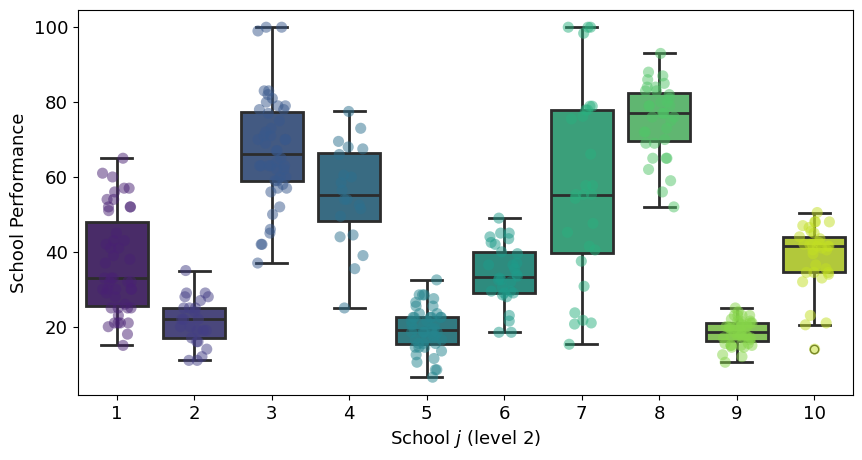

In [10]:
# Students' average performance graph - boxplot - per school

plt.figure(figsize=(10,5))
sns.boxplot(data=student_school_df, x='school', y='performance',
            linewidth=2, orient='v', palette='viridis')
sns.stripplot(data=student_school_df, x='school', y='performance',
              palette='viridis', jitter=0.2, size=8, alpha=0.5)
plt.ylabel('School Performance', fontsize=13)
plt.xlabel('School $j$ (level 2)', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.show()

<Figure size 1000x500 with 0 Axes>

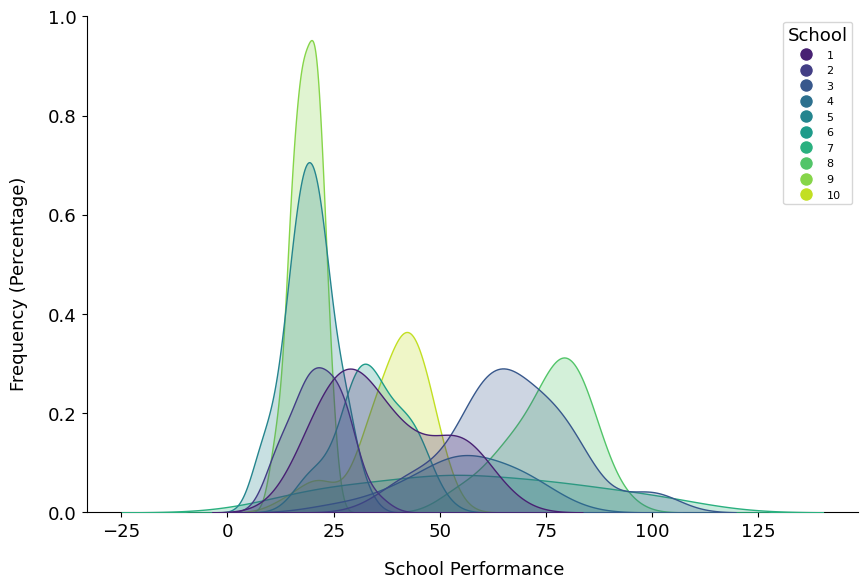

In [11]:
# KDE (probability density function PDF estimate) graph of dependent variable ('performance') - per school

schools = student_school_df['school'].unique()
colors = sns.color_palette('viridis', len(schools))

plt.figure(figsize=(10, 5))
g = sns.pairplot(student_school_df[['school', 'performance']], hue='school',
                 height=5.7,
                 aspect=1.5, palette=colors)
g._legend.remove()
g.set(xlabel=None)
g.set(ylabel=None)
g.tick_params(axis='both', which='major', labelsize=15)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=color,
                              markersize=10, label=school)
                   for school, color in zip(schools, colors)]
plt.legend(handles=legend_elements, title='School', fontsize=8,
           title_fontsize=13)

plt.gcf().text(0.5, -0.01, 'School Performance', ha='center', fontsize=13)
plt.gcf().text(-0.01, 0.5, 'Frequency (Percentage)', va='center', rotation='vertical',
               fontsize=13)

for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=13)
    
plt.show()

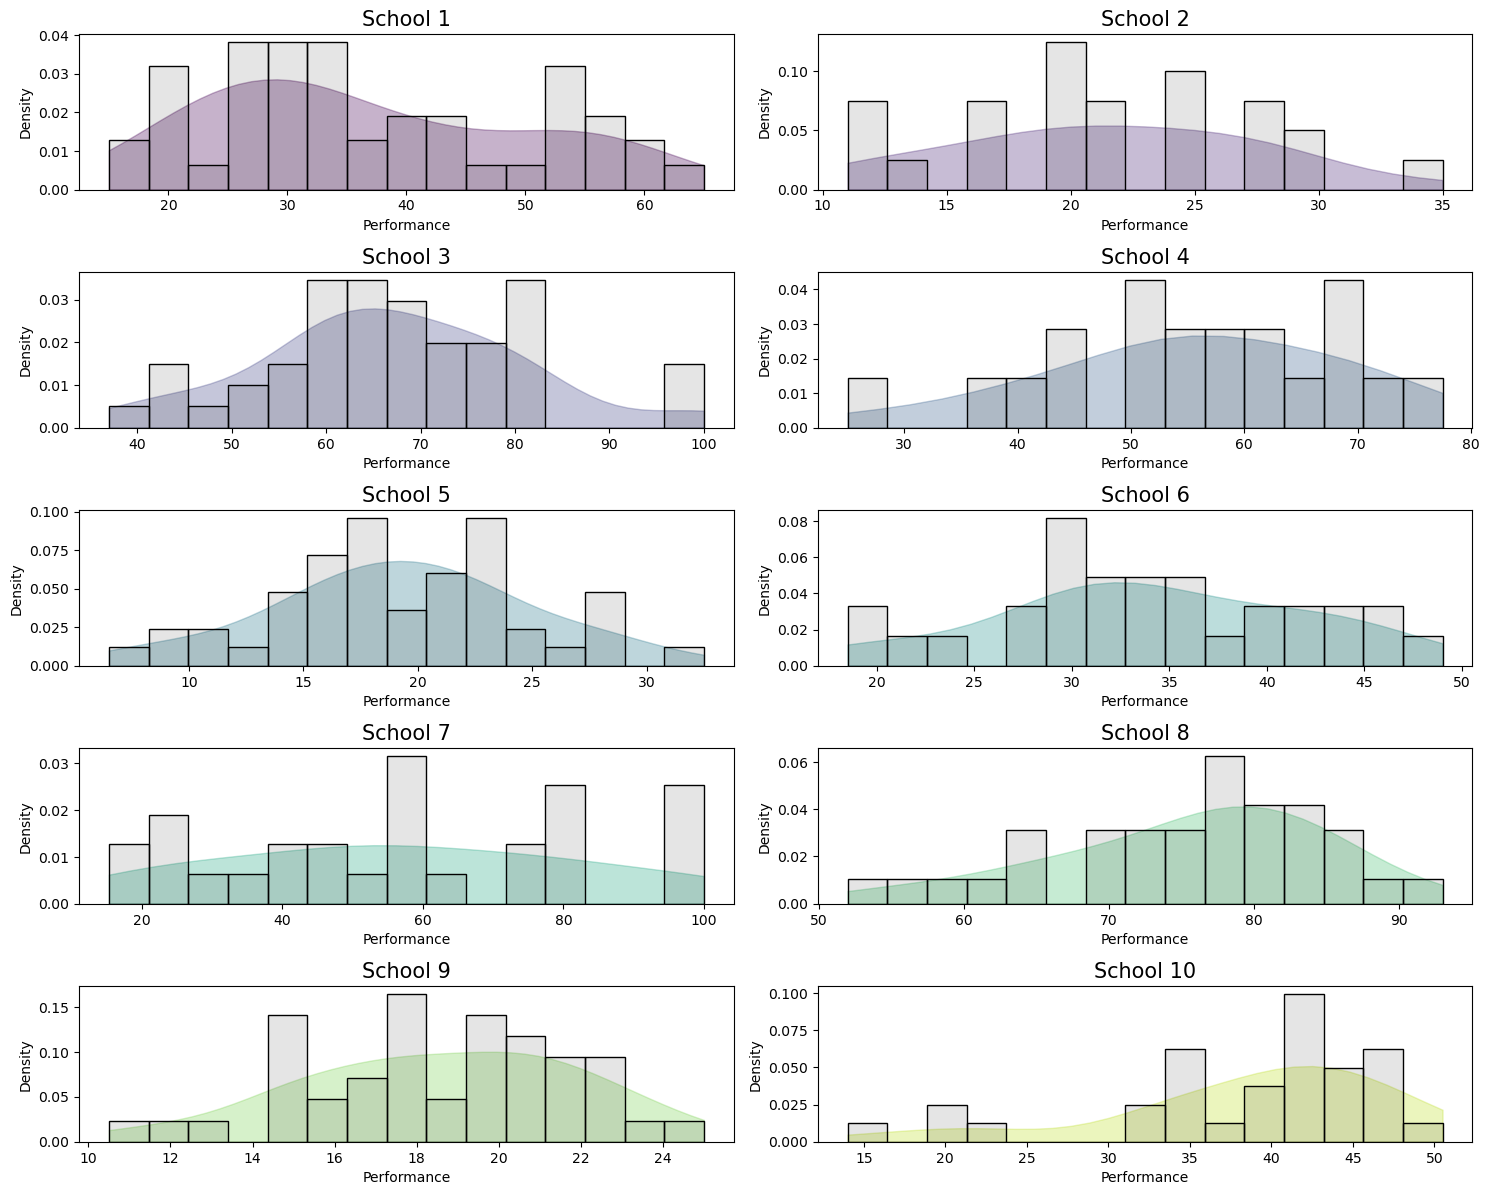

In [12]:
# KDE (probability density function PDF estimate) graph of dependent variable ('performance') and respective histogram
# - per school - separately

schools = student_school_df['school'].unique()

fig = plt.figure(figsize=(15, 14))
gs = GridSpec(len(schools) // 2 + 1, 2, figure=fig)

for i, school in enumerate(schools):
    ax = fig.add_subplot(gs[i])

    # Subset of data per school
    school_df = student_school_df[student_school_df['school'] == school]

    # Density of data
    density = gaussian_kde(school_df['performance'])
    x_vals = np.linspace(min(school_df['performance']),
                         max(school_df['performance']), len(school_df))
    y_vals = density(x_vals)

    # Plotting density area
    ax.fill_between(x_vals, y_vals,
                    color=sns.color_palette('viridis',
                                            as_cmap=True)(i/len(schools)),
                    alpha=0.3)
    
    # Adding histogram
    sns.histplot(school_df['performance'], ax=ax, stat="density", color="black",
                 edgecolor="black", fill=True, 
                 bins=15, alpha=0.1)
    ax.set_title(f'School {school}', fontsize=15)
    ax.set_ylabel('Density')
    ax.set_xlabel('Performance')

plt.tight_layout()
plt.show()

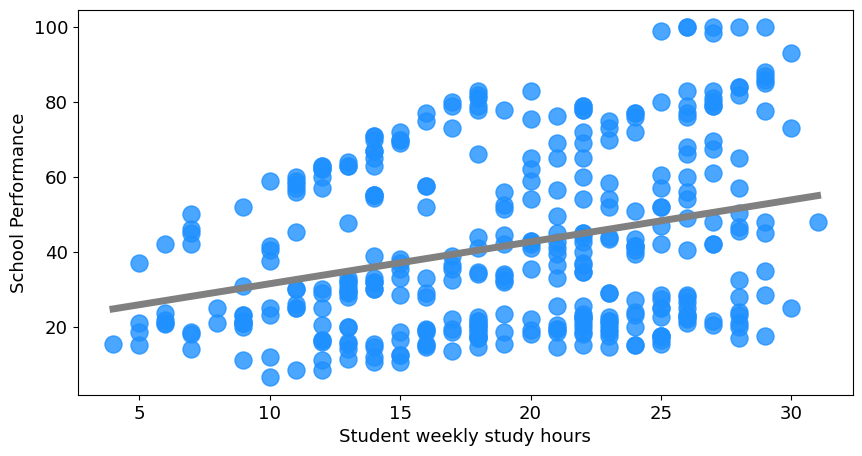

In [13]:
# Performance x study_hours (OLS) - without considering different school contexts - level 2 and considering only 
# level 1 (students as a whole - not seggregated per school)

plt.figure(figsize=(10,5))
sns.regplot(data=student_school_df, x='study_hours', y='performance', marker='o', ci=False,
            scatter_kws={"color":'dodgerblue', 'alpha':0.8, 's':150},
            line_kws={"color":'grey', 'linewidth': 5})
plt.xlabel('Student weekly study hours', fontsize=13)
plt.ylabel('School Performance', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

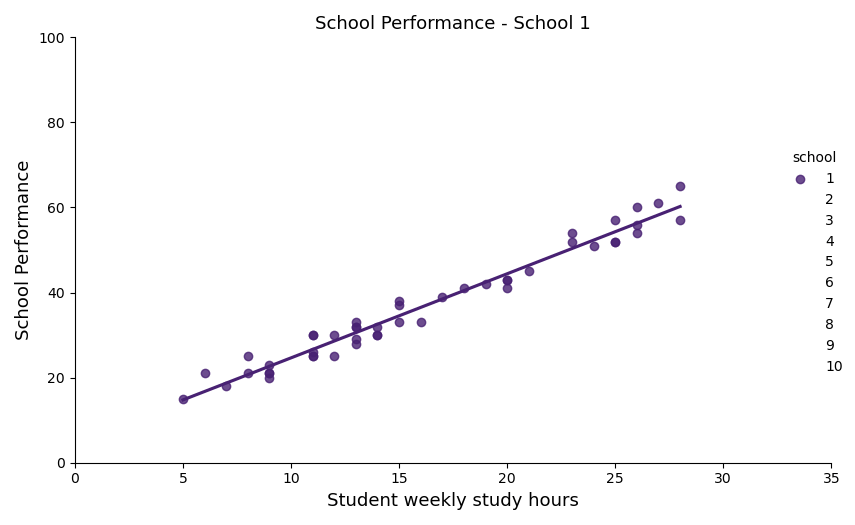

In [14]:
# Performance x study_hours (OLS) - GIF with multiple graph images - per school

# obtaining the school list with unique names
schools = student_school_df['school'].unique()

# defining the number of colors per number of schools
number_colors = len(schools)

# creating school mapping dictionary
corr_school = dict(zip(schools, sns.color_palette('viridis', number_colors)))

# list for storing each gif frame
frames = []

# looping each school and plotting graph only for that school
for school in schools:
    # filtering school for that iteration
    data = student_school_df[student_school_df['school'] == school]
    # creating plot graph for the current school
    sns.lmplot(x='study_hours', y='performance', data=data, hue='school',
               height=5.25, aspect=1.5, ci=False, palette=[corr_school[school]])
    plt.title(f"School Performance - School {school}", fontsize=13)
    plt.xlabel("Student weekly study hours", fontsize=13)
    plt.ylabel("School Performance", fontsize=13)
    plt.yticks(np.arange(0, 101, 20))
    plt.xticks(np.arange(0, 36, 5))
    plt.tight_layout()
    # converting the graph into a canvas img
    plt_canvas = plt.get_current_fig_manager().canvas
    plt_canvas.draw()
    image = np.asarray(plt_canvas.buffer_rgba())  # RGBA
    image = image[:, :, :3]  # convert to RGB
    # add to the list of gif frames
    frames.append(image)
    # cleans the plt for the next iteration
    plt.close()

# saves all frames as a GIF
imageio.mimsave('graphic_schools.gif', frames, fps=1, loop=0)

# shows the gif
display(Image(filename='graphic_schools.gif'))

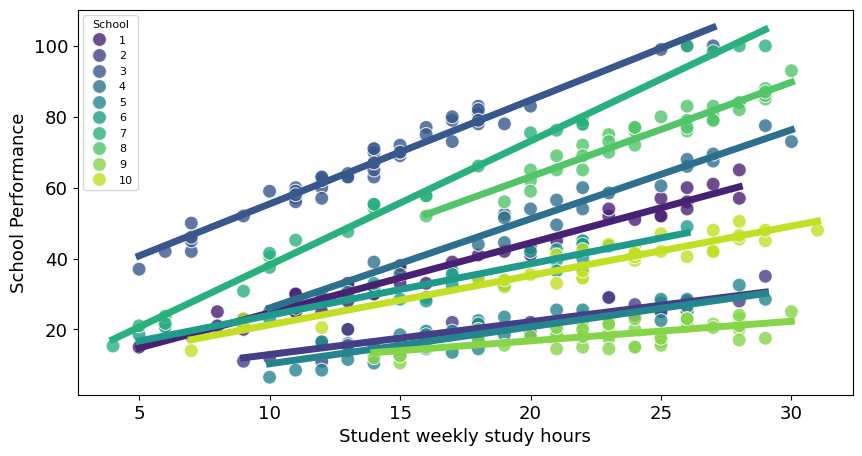

In [15]:
# Performance x study_hours (OLS) plot graph - per school

palette = sns.color_palette('viridis',
                            len(student_school_df['school'].unique()))

plt.figure(figsize=(10,5))
sns.scatterplot(data=student_school_df, x='study_hours', y='performance', hue='school',
                palette=palette, s=100, alpha=0.8, edgecolor='w')

for school in student_school_df['school'].cat.categories:
    subset = student_school_df[student_school_df['school'] == school]
    sns.regplot(data=subset, x='study_hours', y='performance', scatter=False, ci=False,
                line_kws={"color": palette[student_school_df['school'].cat.categories.get_loc(school)], 
                          'linewidth': 5})

plt.xlabel('Student weekly study hours', fontsize=13)
plt.ylabel('School Performance', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(title='School', title_fontsize='8', fontsize='8', loc='upper left')
plt.show()

## Some theory discussion before starting creating multilevel models...

Observe that, for our dataset, if we consider only students’ **study_hours** and their **performance**, without accounting for the different contextual factors associated with each school, we would obtain a traditional OLS regression that is highly heteroscedastic, with large residual errors. This occurs because we ignore important level-2 predictors (such as **professor_experience_years**) that operate at the school level rather than the student level. Additionally, by treating all students as belonging to a single homogeneous context, we fail to capture the variability introduced by differences between schools.

As a result, the variance of the dependent variable is excessively attributed to the residuals, instead of being properly explained by omitted predictors and contextual effects.

In contrast, when using multilevel (nested) regression analysis rather than traditional single-level linear regression, heteroscedasticity is addressed more appropriately. This is because the variance of the dependent variable is explicitly modeled using the relevant predictors, including level-2 variables, and by incorporating the effects of different contextual units (i.e., schools).

In this framework, we effectively estimate one regression per school, allowing each group to have its own relationship structure. This prevents data from different schools from improperly influencing one another’s regression patterns. Consequently, heteroscedasticity is substantially reduced, residual dispersion decreases, and overall model predictive performance improves.

Each level of the data hierarchy represents a layer of context. Each unit within a given level (e.g., level 2) defines a context characterized by variables that are common to all observations within that unit. These contextual variables vary across groups but remain constant within each group. In contrast, level-1 units correspond to individual observations, whose variables vary across observations rather than across groups.

This distinction defines the difference between level-1 (observation-level) variables and level ≥2 (context-level) variables, which may be either latent or explicitly observed. In our case, **study_hours** is a level-1 variable (per student), while **professor_experience_years** is a level-2 contextual variable (per school). Each student has their own value of **study_hours**, whereas all students within the same school share the same value of **professor_experience_years**.

Both intercepts (α or β₀) and slopes (β₁, β₂, …) can be allowed to vary randomly across level-2 units (schools). These are known as random effects. So far, we have illustrated these concepts graphically; next, we formalize them algebraically and test their statistical significance.

We construct the multilevel model incrementally (a step-up approach), comparing each stage to the traditional linear regression model. Since standard stepwise procedures are not typically applied to hierarchical linear models (HLM), this progressive approach is preferred.

First, we test the statistical significance of ν₀ⱼ, which represents the random effect associated with the intercept at level 2. This allows us to determine whether the intercept varies significantly across schools. If ν₀ⱼ is statistically equal to zero, there is no meaningful difference between schools in terms of intercepts, and all regressions share the same starting point on the Y-axis. In this initial model, no predictors are included other than the intercept (β₀).

If ν₀ⱼ is significantly different from zero, then intercepts vary across schools, indicating between-group variability at level 2.

Next, we estimate a model that includes both ν₀ⱼ and ν₁ⱼ, representing the random effects of the intercept and slope(s), respectively. If ν₁ⱼ is statistically equal to zero, the effect of the predictor(s) is constant across schools; otherwise, it varies between contexts. Thus, nonzero values of ν₀ⱼ and/or ν₁ⱼ indicate that intercepts and/or slopes differ across level-2 units.

In summary, if ν₀ⱼ and/or ν₁ⱼ are significantly different from zero, multilevel models (HLM or GLMM) are more appropriate than traditional linear regression. Only when both ν₀ⱼ and ν₁ⱼ are equal to zero does the model reduce to a standard linear regression, which can be viewed as a special case of a multilevel model.

In the final stage of the step-up process, we incorporate both random effects (ν₀ⱼ and ν₁ⱼ) and fixed predictors at levels 1 and 2, yielding the full specification of a two-level HLM/GLMM. This final model typically provides the best predictive performance.

As additional levels of hierarchy are introduced, more steps and variables must be included for each level. The formulation presented here applies to two-level models; three-level models require additional hierarchical structures and parameters (see an example at this same directory).

Finally, it is important not to impose artificial hierarchical structures on the data. The nesting must already exist in the dataset. The goal is to model the inherent structure of the data, including its natural hierarchical relationships.

## Some famous quotations from scientific papers and academic books:

1 ) “If the variances of the random terms ν₀ⱼ and ν₁ⱼ are statistically different from zero, traditional procedures for estimating the model parameters, such as ordinary least squares, are not appropriate.” 

Using Multivariate Statistics (by Hair, Black, Babin, and Anderson, 6th ed., Pearson, 2013)

2 ) Goldstein and other key texts (e.g., Hox, Snijders & Bosker, Raudenbush & Bryk) explain that traditional single-level regression (OLS) has serious limitations with hierarchical/clustered data because it:

- Ignores the hierarchical structure and intra-class correlation.
- Treats all observations as independent (wrong when data are clustered).
- Only models a single fixed-effects part and a single homogeneous error term.
- Cannot properly handle random coefficients (slopes that vary across groups) or cross-level interactions.

Goldstein (2011 and earlier editions):

“To ignore this [hierarchical structure] risks overlooking the importance of group effects, and may also render invalid many of the traditional statistical analysis techniques used for studying data relationships.”
He repeatedly contrasts the fixed part (systematic effects + interactions) with the random part (random effects at different levels + complex variance-covariance structure).

Common explanation in textbooks:
Traditional regression models assume a single error term and do not allow coefficients to vary randomly across groups, nor do they model interactions between predictors in the fixed part and the random structure (e.g., random slopes and their covariances with residuals).

A very close conceptual match (from a 2019 paper on multilevel modeling for longitudinal data):
“As multilevel models allow interactions between variables in the fixed effects component and, more than that, allow interactions between [variables and] random effects... The absence of random terms for each contextual effect in traditional regression models... prevents greater adherence...”

In short:

Traditional regression models ignore the interactions between variables (e.g. Xij and Wj) in the fixed effects component and the interactions between error terms and variables (ν1j and Xij) in the random effects component.

3 ) “The inclusion of group dummy variables alone does not capture contextual effects, because it does not allow the separation of observed and unobserved effects on the dependent variable.”

Multilevel and Longitudinal Modeling Using Stata (Rabe-Hesketh & Skrondal, 3rd ed., Stata Press, 2012).

Group dummies (fixed effects only):
- Control for average differences between groups, but do not model random variation
- Cannot separate unobserved heterogeneity from residual structure

Multilevel models:
- Explicitly model random effects
- Allow decomposition of: within-group variance and between-group variance
- Capture true contextual effects

4 ) “Multilevel models thus allow the development of new and more refined constructs for prediction and decision-making. Within a single-equation modeling framework, there appears to be no connection between individuals and the society in which they live. In this sense, the use of multilevel equations enables the researcher to ‘jump’ from one level of analysis to another—individuals and societies, students and schools, families and neighborhoods, firms and countries. Ignoring these relationships leads to incorrect analyses of individual behavior and, likewise, of group behavior. Only by recognizing these reciprocal influences is it possible to correctly analyze social phenomena.”

Methodology and Epistemology of Multilevel Analysis by Daniel Courgeau, 2003.

Courgeau is making a methodological and epistemological claim:
- Traditional models → isolate individuals
- Reality → individuals are embedded in hierarchical social structures
- Multilevel models → explicitly connect: micro level (individuals) and macro level (contexts)

Ignoring this structure produces systematically biased interpretations, not just inefficient estimates.

5 ) “The use of multilevel models may be limited by several factors, including: 
(1) the structure of the data; 
(2) failure to recognize the multilevel nature of the data; and 
(3) insufficient computational capacity, particularly when complex interactions are present.”

Multilevel Network Analysis for the Social Sciences, 2016.

It highlights practical limitations of multilevel modeling:

Data structure
→ If the hierarchy is weak, poorly defined, or unbalanced, multilevel models lose effectiveness

Conceptual misspecification
→ If researchers ignore hierarchy, they misuse single-level models

Computational constraints
→ Especially relevant for:
- random slopes
- cross-level interactions
- network + multilevel combinations

Even today, this last point still matters for very large or complex models (though less than in 2016).

## Back to our use-case Multilevel Modeling...

![./null-model.png](./null-model.png)

![./icc.png](./icc.png)

### **Step 1 - Modeling the null model**
We ignore level-1 predictors and include only the intercept at level 1 (β₀ⱼ), along with its fixed component (γ₀₀) and random effect (ν₀ⱼ) at level 2, as well as the level-1 residual (εᵢⱼ), which introduces additional randomness into the model.

“Class” here is used as a synonym for context or level-2 unit—i.e., a cluster of observations belonging to the same group. Regarding the random components, εᵢⱼ is a *within-class (level-1) random error*, which varies across observations *i* within classes *j*. In contrast, ν₀ⱼ is a *between-class (level-2) random effect*, which varies across classes but is constant for all observations within the same class.

We quantify the degree of clustering using the intraclass correlation coefficient (ICC), defined as the proportion of total variance attributable to between-class variation. Formally, the ICC is given by the formula at the above image.

The ICC indicates how much of the variance in the dependent variable is explained by differences between level-2 units, independently of level-1 predictors. In our example, it reflects how much of the variation in performance is associated with school-level factors (such as **professor_experience_years**) relative to the total variation, which also includes student-level residual variability.

Using the null model, we test whether the variance of ν₀ⱼ is statistically different from zero. If it is, this indicates significant between-group variability and supports the use of multilevel models (HLM or GLMM) rather than traditional single-level models (GLM/OLS).

In subsequent models, we also test ν₁ⱼ, the random slope component. If ν₁ⱼ is statistically different from zero, this indicates that the effect of the predictor varies across groups.

In summary, if either ν₀ⱼ (random intercept) or ν₁ⱼ (random slope) is significantly different from zero, a multilevel model is required. Only when both variance components are not significantly different from zero can the model be simplified to a traditional single-level regression (GLM/OLS), which is then understood as a special case of the multilevel framework.

In [16]:
# defining the null model
hlm2_null_model = sm.MixedLM.from_formula(formula='performance ~ 1',
                                           groups='school',
                                           re_formula='1',
                                           data=student_school_df).fit()
hlm2_null_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: performance
No. Observations: 358     Method:             REML       
No. Groups:       10      Scale:              142.9242   
Min. group size:  20      Log-Likelihood:     -1416.0074 
Max. group size:  48      Converged:          Yes        
Mean group size:  35.8                                   
---------------------------------------------------------
                Coef.  Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       42.387    6.468 6.553 0.000 29.709 55.065
school Var     414.067   16.695                          
=========================================================

"""

In [17]:
# "Intercept" is the level-2 fixed component (γ₀₀), the fixed part of the level-1 intercept at level-2 context layer. 
# It is the grand mean of performance across all students and all schools. On average, students score about 42.39 
# points. Estimates the overall average performance. It doesn't vary eiher with different i observations or with 
# different j classes.

# "school Var" is the level-2 inter-class variance - σ²(ν₀ⱼ) - the variance of the random part of the level-1 
# intercept at level-2 context layer. This is the between-school variance and tells you how much schools differ from 
# each other in their average performance. It varies only between different classes, but not between different 
# observations, within one same class. It is influenced by context variables, e.g. professor_experience_years - school 
# level, but not by observations' variables, e.g. study_hours - student level.

# "Scale" is the level-1 residual variance (σ²ε) — the within-school variance of performance after accounting for school 
# differences. It varies between different observations, including intra-class (from one same context).

# Log-Likelihood: like the other regression analysis types, Log-likelihood of the model is used for model comparison 
# (lower = worse fit).

How to calculate ICC from this output:
$$\text{ICC} = \frac{\text{school Var}}{\text{school Var} + \text{Scale}} = \frac{414.067}{414.067 + 142.9242} \approx 0.743 \ (74.3\%)$$
Interpretation:

About 74.3% of the total variation in performance is due to differences between schools.
Only 25.7% is due to differences between students within the same school.

This is a very high ICC, suggesting strong school-level clustering. Multilevel modeling is definitely appropriate here.

In [18]:
# the only fixed part of the above model equation is the γ₀₀, which is 42.387, the overall mean for Performance.
# The other two params of the regression formula - ν₀ⱼ and εij - are given as a variance. Their value will vary
# accordingn to each observation and/or class. So that there's not a single value we can substitute to define a one
# single (global) regression expression. What we know are the variances of such params, and therefore their standard 
# deviations (sd) regarding the overall fixed mean (γ₀₀), so that, for this partial intermediate model, the Yhat
# Performance would vary 42.387 +- 20.35 regarding different schools (inter-class variation, random school effects), 
# and 42.387 +- 11.96 regarding each different student (intra-class variation, student residuals). Each context will
# have its own regression line and expression, and their own observabtions clusters (students). Any prediction is done
# on each specific level-2 regression context.

### What is **REML**?

**REML** stands for **Restricted Maximum Likelihood** (also called **Residual Maximum Likelihood**).

It is the default method used by `statsmodels.MixedLM` (and by packages like `lme4` in R) when fitting **mixed-effects models** (hierarchical/multilevel models).

#### Why "Restricted"?
- In a normal linear model, when you estimate the **fixed effects** (like the intercept γ₀₀), you "use up" some degrees of freedom.
- Regular **Maximum Likelihood (ML)** ignores this loss of degrees of freedom when estimating the **variance components** (school variance and residual variance). As a result, ML tends to **underestimate** the variances (especially when the number of groups or fixed effects is not very large).
- **REML** fixes this problem by using a clever mathematical trick: it estimates the variance components based on the **residuals** after accounting for the fixed effects. This makes the variance estimates **less biased** (closer to the true population values).

In your null model:
- School variance (`school Var`) = 414.067
- Residual variance (`Scale`) = 142.924

These numbers are estimated using **REML**, so they are more trustworthy than if the model had used plain Maximum Likelihood.

---

### Difference between **REML** and **OLS**

Here's a simple comparison:

| Aspect                      | **OLS** (Ordinary Least Squares)                  | **REML** (in Mixed Models)                          |
|----------------------------|----------------------------------------------------|-----------------------------------------------------|
| **Purpose**                | Estimate fixed effects (coefficients)             | Estimate **variance components** (random effects)  |
| **What it assumes**        | All observations are independent                  | Observations are clustered (e.g., students in schools) |
| **Handles clustering?**    | No — treats all data as independent               | Yes — explicitly models school-level variation     |
| **Estimates variances**    | Gives one single residual variance (MSE)          | Separates **between-school** variance + **within-school** variance |
| **Bias in variances**      | Not applicable in the same way                    | Less biased (better) than regular ML               |
| **Best for**               | Simple linear regression                          | Multilevel / hierarchical / mixed models           |
| **Your null model**        | Would ignore school clustering                    | Correctly accounts for it (that's why you used MixedLM) |

**Key takeaway:**

- **OLS** is what you use for ordinary linear regression (`sm.OLS`).
- When your data has a nested structure (students inside schools), OLS gives **wrong standard errors** and **ignores important variance partitioning**.
- **REML** is the modern, preferred way to estimate the random effects (variances) in mixed models.

### Practical Rules of Thumb

- Use **REML** (default) when your main goal is to estimate **variance components** accurately or to get good predictions.
- Use **Maximum Likelihood (ML)** instead when you want to compare **different fixed-effects models** using likelihood ratio tests (REML is not ideal for that).
- Since this is a **null model** focused on variance partitioning (ICC), REML is the better choice.


In [19]:
# significance analysis of the intercept random effects (is ν₀ⱼ significantly different from zero ?)

test = float(hlm2_null_model.cov_re.iloc[0, 0]) /\
    float(pd.DataFrame(hlm2_null_model.summary().tables[1]).iloc[1, 1])

p_value = 2 * (1 - stats.norm.cdf(abs(test)))

print(f"Z statistics regarding the significance of contextual random effects for the intercept (β₀ⱼ): {test:.3f}")
print(f"P-valor: {p_value:.3f}")

if p_value >= 0.05:
    print("Negative statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.")
else:
    print("Positive statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.")

Z statistics regarding the significance of contextual random effects for the intercept (β₀ⱼ): 24.802
P-valor: 0.000
Positive statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.


In [20]:
# the positive test above, for ν₀ⱼ significance, proves what we already suspected from the OLS plot graphs per school 
# and ICC, which is the fact that at least ν₀ⱼ differs between contexts, and, therefore, level-1 intercept, as well. 
# So, for each context (or school), we will have a different intercept at the specific context regression expression, 
# 74.3% of this intercept variance explained by level-2 ν₀ⱼ variation (inter-class variance between schools) and only 
# 25.7% due to level-1 εij variation (intra-class variance between students, or level-1 residuals). This, alone, proves 
# we have to use GLMM or HLM models and not classic GLM models, for best predictivity, even without having evaluated 
# the significance of ν₁ⱼ yet. If ν₀ⱼ wasn't significant, we'd still have to check the significance of ν₁ⱼ, before
# discarding multilevel analysis necessity and being able to safely choose traditional GLM instead (both should be 0).

In [21]:
# Defining a traditional OLS model (GLM) for comparing predictability with the GLMM/HLM model we defined above:

ols_null_model = sm.OLS.from_formula(formula='performance ~ 1',
                                      data=student_school_df).fit()
ols_null_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 04 May 2026   Prob (F-statistic):                nan
Time:                        10:09:55   Log-Likelihood:                -1633.5
No. Observations:                 358   AIC:                             3269.
Df Residuals:                     357   BIC:                             3273.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5542      1.228     33.852      0.000      39.140      43.968
==============================================================================
Omnibus:                       38.443   Durbin-Watson:                   0.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.903
Skew:                           0.626   Prob(JB):                     1.95e-07
Kurtosis:                       2.291   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

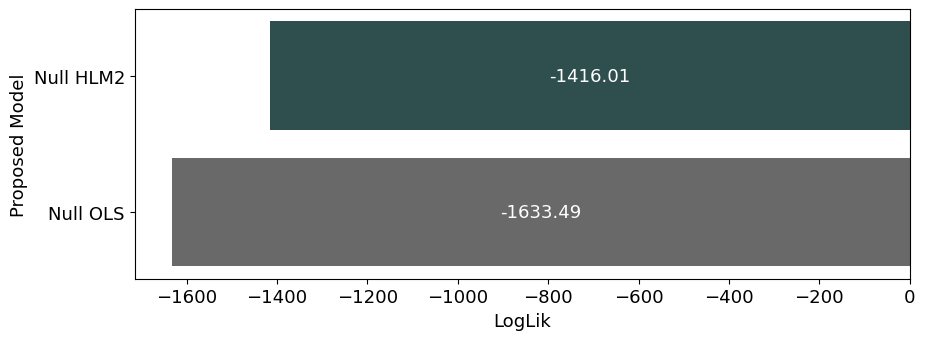

In [22]:
# visually comparing the two models logliks

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM2'],
                      'loglik':[ols_null_model.llf,hlm2_null_model.llf]})

fig, ax = plt.subplots(figsize=(10,3.5))

c = ['dimgray','darkslategray']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [23]:
# LLR test between these two Null (intermediate) models: ols_null_model and hlm2_null_model, in order to confirm 
# their llf difference, statistically

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llf
    llk_2 = model_1.llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 1) # 1 degree of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")

lrtest([ols_null_model, hlm2_null_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 434.96
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [24]:
# we proved again the superiority of GLMM/HLM over GLM/OLS, only by considering the variance of the intercept of the 
# models, although not yet the predictors. The difference in LogLikelihood (LLF) between these two Null models, and 
# the better LL at the GLMM/HLM model, is solely due to the ν₀ⱼ inter-class significant variantion, that is, the 
# significant random effect of the variant part of the level-1 intercept between level-2 different contexts (schools).

![./intercept-slope-model.png](./intercept-slope-model.png)

### Random Intercept and Random Slope Model (without Level-2 predictor $W$)

Continuing our step up approach, we now model both the intercept and the slope of the Level-1 predictor $X$ (*study_hours*), while temporarily excluding the Level-2 predictor $W$ (*professor_experience_years*).

**Level 1:**
$$
Y_{ij} = \beta_{0j} + \beta_{1j} X_{ij} + \varepsilon_{ij}
$$

**Level 2:**
$$
\beta_{0j} = \gamma_{00} + v_{0j}
$$

$$
\beta_{1j} = \gamma_{10} + v_{1j}
$$

---

### Combined Model

$$
Y_{ij} =
\gamma_{00}
+ \gamma_{10} X_{ij}
+ v_{0j}
+ v_{1j} X_{ij}
+ \varepsilon_{ij}
$$

---

### Interpretation

We extend the previous null (intercept-only) model by introducing:

- The Level-1 predictor $X_{ij}$ (*study_hours*)  
- A **random slope component** $v_{1j}$, allowing the effect of $X$ to vary across groups (schools)

Thus, we now model:

- Between-group variability in intercepts via $v_{0j}$  
- Between-group variability in slopes via $v_{1j}$  
- Within-group variability via $\varepsilon_{ij}$  

---

### Statistical Testing Logic

- We already established that $v_{0j} \neq 0$: intercepts vary across schools  
- Now we test whether $v_{1j} \neq 0$: do slopes also vary across schools?

If:

- $v_{1j} = 0$ → slopes are constant across groups → random intercept model  
- $v_{1j} \neq 0$ → slopes vary across groups → random intercept + random slope model  

---

### Modeling Implications

A standard OLS/GLM model would only be appropriate if:

$$
v_{0j} = 0 \quad \text{and} \quad v_{1j} = 0
$$

meaning no between-group variation at all.

Since $v_{0j} \neq 0$, a multilevel (mixed-effects) model is already required.

The remaining question is whether only intercepts vary or both intercepts and slopes vary across schools.

---

### Key Structural Insight

- $v_{0j}$ shifts the intercept (does not interact with predictors)  
- $v_{1j}$ modifies the slope (interacts directly with $X_{ij}$)  

---

### Practical Specification (conceptual)

- Fixed effects: $1 + X$  
- Random effects: $1 + X \mid \text{school}$

In [25]:
# defining intercept + slope model (without W) by improving the null model to include also the level-1 predictor and 
# its slope coefficient, having both level-1 intercept and slope random effects modeled at the nested model expression 
# (see formulas above). Now, instead of passing 1, we pass study_hours at the formula param, as well as at the 
# re_formula param (see below). At formula param study_hours enters as the level-1 predictor we're now including at 
# the model, while, at re_formula param, study_hours enters as the variable that interacts with the ν₁ⱼ slope random 
# effect (modeling heteroscedasticity). The ν₀ⱼ intercept random effect never interacts with any variable.

intercept_slope_hlm2_model = sm.MixedLM.from_formula(formula='performance ~ study_hours',
                                                       groups='school',
                                                       re_formula='study_hours',
                                                       data=student_school_df).fit()

intercept_slope_hlm2_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:               MixedLM    Dependent Variable:    performance
No. Observations:    358        Method:                REML       
No. Groups:          10         Scale:                 7.0497     
Min. group size:     20         Log-Likelihood:        -906.8028  
Max. group size:     48         Converged:             Yes        
Mean group size:     35.8                                         
------------------------------------------------------------------
                         Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                 7.121    2.426 2.935 0.003  2.366 11.875
study_hours               1.895    0.308 6.158 0.000  1.292  2.498
school Var               55.078   10.278                          
school x study_hours Cov  2.568    0.986                          
study_hours Var           0.938    0.170                          
==================================================================

"""

In [26]:
# "Intercept" is the level-2 fixed component (γ₀₀) for the level-1 intercept (β₀ⱼ). It is the grand mean of performance 
# across all students and all schools. On average, students score about 7.121 points. Estimates the overall average 
# performance. It doesn't vary eiher with different i observations (students) or with different j classes (schools). 
# It does not model random effects.

# "study_hours" is the level-2 fixed component (γ₁₀) for the level-1 study_hours predictor coefficient (β₁ⱼ). It is 
# not the predictor itself (which varies for each observation - student). γ₁₀ doesn't vary eiher with different i 
# observations (students) or with different j classes (schools). It does not model random effects.

# "school Var" is the level-2 inter-class intercept variance component - σ²(ν₀ⱼ) - the variance of the random part of 
# the level-1 intercept at level-2 context layer. This is the between-school intercept variance and tells you how much 
# schools differ from each other in their average performance, because of intercept variation. It varies only between 
# different j classes, but not between different i observations, within one same class.

# "study_hours Var" is the level-2 inter-class slope variance component - σ²(ν₁ⱼ) - the variance of the random part 
# of the level-1 study_hours predictor coefficient (β₁ⱼ) at level-2 context layer. This is the between-school slope 
# variance and tells you how much schools differ from each other in their average performance, because of slope 
# variation. It varies only between different j classes, but not between different i observations, within one same 
# class.

# "Scale" is the level-1 residual variance (σ²ε) — the within-school variance of performance after accounting for 
# school differences. It varies between different observations, including intra-class (from one same context).

# Observe all coefficients change, as we improve the model, each step up, so we gotta test again the significance of 
# the difference to zero for each random effect coefficient (ν₀ⱼ and, now, ν₁ⱼ). If any of these "νⱼ" is different 
# from 0, we still have a GLMM / HLM case.

In [27]:
# testing if the random effect coefficients (intercept: ν₀ⱼ and slope: ν₁ⱼ), are statistically different from zero

# if p >= 0.05, there's no significance, therefore no difference from zero, and no contextual random effect regarding
# the intercept or slope (whatever is being tested) => ν₀ⱼ and/or ν₁ⱼ is zero => if both zero, it could be GLM / OLS 
# model;
# if p < 0.05, there is significance, therefore there is difference from zero, and contextual random effect regarding
# the intercept or slope (whatever is being tested) => ν₀ⱼ and/or ν₁ⱼ is different from zero => must be GLMM / HLM 
# model;

# if ν₀ⱼ ≠ 0, each regression line differs vertically, in parallel - intercept variation according to context (school);
# if ν₁ⱼ ≠ 0, each regression line differs in inclination (slope), angularly - slope variation according to context 
# (school);
# if both ν₀ⱼ and ν₁ⱼ ≠ 0, each regression line differs both vertically, in parallel, as in inclination (slope).

# for intercept: ν₀ⱼ

test = float(intercept_slope_hlm2_model.cov_re.iloc[0, 0]) /\
    float(pd.DataFrame(intercept_slope_hlm2_model.summary().tables[1]).iloc[2, 1])

p_value = 2 * (1 - stats.norm.cdf(abs(test)))

print(f"Z statistics regarding the significance of contextual random effects (ν₀ⱼ) for the intercept (β₀ⱼ): {test:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value >= 0.05:
    print("Negative statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.")
else:
    print("Positive statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.")

# for slope: ν₁ⱼ

test = float(intercept_slope_hlm2_model.cov_re.iloc[1, 1]) /\
    float(pd.DataFrame(intercept_slope_hlm2_model.summary().tables[1]).iloc[4, 1])

p_value = 2 * (1 - stats.norm.cdf(abs(test)))

print(f"\nZ statistics regarding the significance of contextual random effects (ν₁ⱼ) for the slope (β₁ⱼ): {test:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value >= 0.05:
    print("Negative statistical significance of contextual random effects regarding the slope, at a confidence level of 95%.")
else:
    print("Positive statistical significance of contextual random effects regarding the slope, at a confidence level of 95%.")

Z statistics regarding the significance of contextual random effects (ν₀ⱼ) for the intercept (β₀ⱼ): 5.359
P-value: 0.000
Positive statistical significance of contextual random effects regarding the intercept, at a confidence level of 95%.

Z statistics regarding the significance of contextual random effects (ν₁ⱼ) for the slope (β₁ⱼ): 5.518
P-value: 0.000
Positive statistical significance of contextual random effects regarding the slope, at a confidence level of 95%.


In [28]:
# In the case of this intermediate model, we have contextual random variance (per school) on the dependent variable 
# (performance) both due to intercept as to slope significant variations - which corroborates the fact we must use 
# GLMM / HLM and not GLM / OLS.

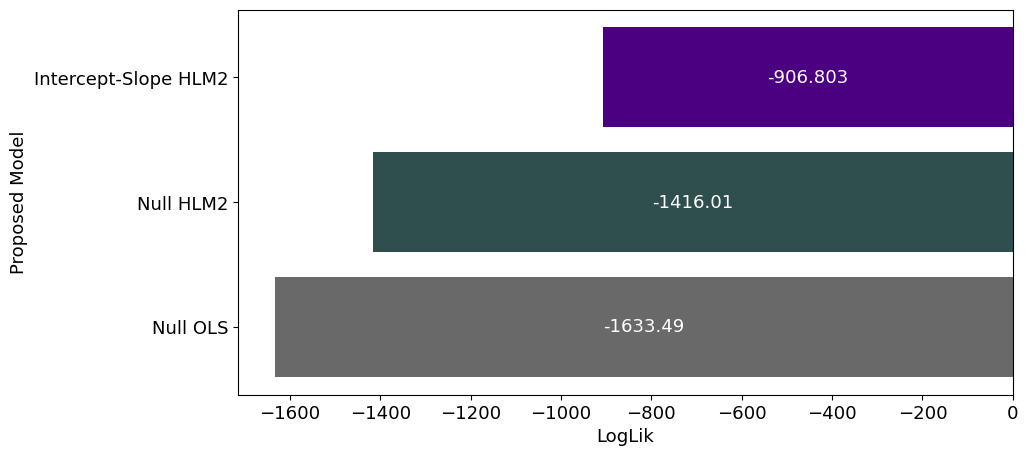

In [29]:
# Plot graph comparing logLiks of models defined up until now:

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM2',
                                 'Intercept-Slope HLM2'],
                      'loglik':[ols_null_model.llf,hlm2_null_model.llf,
                                intercept_slope_hlm2_model.llf]})

fig, ax = plt.subplots(figsize=(10,5))

c = ['dimgray','darkslategray','indigo']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [30]:
# LLR test between both HLM models thus far: hlm2_null_model and intercept_slope_hlm2_model, in order to confirm 
# their llf difference, statistically. LLR test between ols_null_model and hlm2_null_model we had already done up 
# above, with positive result.

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llf
    llk_2 = model_1.llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 2) # 2 degrees of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")

lrtest([hlm2_null_model, intercept_slope_hlm2_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 1018.41
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [31]:
# So far, from all models defined, all of them had statistically different Log Likelihood values, and the one with the
# highest llf has been the Intercept-Slope HLM2 model, with significant random effects on student performance, at 
# different contextual units (schools), specifically due to significant variance on the intercept (ν₀ⱼ) - i.e. on 
# the mean values of the dependent variable - and also significant variance on the slope (ν₁ⱼ) - i.e. on the slope 
# of increase rate of the dependent variable - at each context (school) regression line. All this level-2 contextual 
# variance happens in addition to the level-1 variance - due to students themselves (εᵢⱼ residuals), and also from the 
# different predictors' values, at each observation. So we have variance on both levels.

# We still gotta go one step up in improving our model, in order to add the level-2 predictive variable W 
# (professor_experience_years) into our modeling, and check if that improves our LLF (predictability) any better.

![./intercept-slope-model-final.png](./intercept-slope-model-final.png)

### **Analysis & Explanation of the Model (Final HLM2)**

### 1. Level 1 Model (Individual / Student level)

$$
performance_{ij} = \beta_{0j} + \beta_{1j} \cdot study\_hours_{ij} + \varepsilon_{ij}
$$

- **What it means**: For each student *i* of professor *j*, their performance is predicted by how many hours they study.
- $\beta_{0j}$ = Intercept for professor *j* (baseline performance when study hours = 0).
- $\beta_{1j}$ = Slope for professor *j* (effect of one additional study hour on performance).
- $\varepsilon_{ij}$ = Residual error (unexplained variation at the student level).

---

### 2. Level 2 Model (School level)

$$
\begin{cases}
\beta_{0j} = \gamma_{00} + \gamma_{01} \cdot professor\_experience\_years_j + v_{0j} \\[8pt]
\beta_{1j} = \gamma_{10} + \gamma_{11} \cdot professor\_experience\_years_j + v_{1j}
\end{cases}
$$

- This explains why different schools have different baselines and different returns to studying.
- Professor experience (in years) is used as a **Level 2 predictor**.

**Interpretation of coefficients**:
- $\gamma_{00}$: Grand mean intercept (average baseline performance across all schools).
- $\gamma_{01}$: Effect of professor experience on baseline performance.
- $\gamma_{10}$: Average slope (average effect of study hours across all schools).
- $\gamma_{11}$: **Cross-level interaction** — how professor experience *moderates* the effect of study hours.
- $v_{0j}$ and $v_{1j}$: Random effects (residual variation between schools).

---

### 3. Combined (Substituted) Model

This is the most important version — it shows everything in one equation:

$$
\begin{align}
performance_{ij} &= \gamma_{00} + \gamma_{10} \cdot study\_hours_{ij} + \gamma_{01} \cdot professor\_experience\_years_j \\
&\quad + \gamma_{11} \cdot professor\_experience\_years_j \cdot study\_hours_{ij} \\
&\quad + v_{0j} + v_{1j} \cdot study\_hours_{ij} + \varepsilon_{ij}
\end{align}
$$

### Key Components Breakdown:

| Term | Type | Meaning |
|------|------|--------|
| $\gamma_{00}$ | Fixed | Overall average performance |
| $\gamma_{10} \cdot study\_hours$ | Fixed | Main effect of studying |
| $\gamma_{01} \cdot prof\_exp$ | Fixed | Main effect of professor experience on baseline |
| $\gamma_{11} \cdot prof\_exp \cdot study\_hours$ | Fixed | **Interaction**: Does more experienced professors make study hours more (or less) effective? |
| $v_{0j}$ | Random | Professor-specific deviation in baseline performance |
| $v_{1j} \cdot study\_hours$ | Random | Professor-specific deviation in the effectiveness of studying |
| $\varepsilon_{ij}$ | Random | Student-level residual |

---

### What This Model Allows You To Test

1. **Does studying improve performance on average?** → Look at $\gamma_{10}$
2. **Do more experienced professors have students with higher baseline performance?** → Look at $\gamma_{01}$
3. **Do more experienced professors make studying more effective?** → Look at $\gamma_{11}$ (the most interesting coefficient in many cases)
4. **How much variation exists between professors** (after controlling for experience)? → Variance of $v_{0j}$ and $v_{1j}$

---

### Model Type Summary

- **Random Intercept + Random Slope** model with a **cross-level interaction**.
- It properly accounts for the hierarchical structure of the data (students clustered within schools), avoiding the problems of regular OLS regression (which would underestimate standard errors).


In [32]:
# defining intercept + slope model (with W level-2 predictor) by improving the intercept + slope model (without W) 
# model to include also the level-2 predictor - i.e. professor_experience_years. This W predictor will model both
# the level-2 intercept (β₀ⱼ) as the level-2 slope (β₁ⱼ) expressions, which later are substituted at level-1 
# regression expression, which now is the final regression formula, as it now includes all level-1 betas and residuals,
# and all level-2 fixed gamas and context-variant nis, as well as the level-2 predictor W.

# Now, instead of passing study_hours, we pass study_hours + professor_experience_years + 
# study_hours:professor_experience_years at the formula param, as well as study_hours at the re_formula param (see 
# below). At formula params study_hours enters as the level-1 predictor, professor_experience_years as the level-2
# predictor, study_hours:professor_experience_years as the nested level1:level2 predictors, while, at re_formula 
# param, study_hours enters as the variable that interacts with the ν₁ⱼ slope random effect (modeling 
# heteroscedasticity). The ν₀ⱼ intercept random effect never interacts with any variable.

intercept_slope_final_hlm2_model = sm.MixedLM.from_formula(formula='performance ~ study_hours +\
                                    professor_experience_years + study_hours:professor_experience_years',
                                    groups='school',
                                    re_formula='study_hours',
                                    data=student_school_df).fit()

intercept_slope_final_hlm2_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                    MixedLM         Dependent Variable:         performance
No. Observations:         358             Method:                     REML       
No. Groups:               10              Scale:                      7.0443     
Min. group size:          20              Log-Likelihood:             -894.5684  
Max. group size:          48              Converged:                  Yes        
Mean group size:          35.8                                                   
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              -0.850    2.999 -0.283 0.777 -6.727  5.028
study_hours                             0.713    0.321  2.225 0.026  0.085  1.342
professor_experience_years              1.585    0.487  3.256 0.001  0.631  2.540
study_hours:professor_experience_years  0.232    0.053  4.405 0.000  0.129  0.335
school Var                             24.345    5.167                           
school x study_hours Cov               -2.354    0.514                           
study_hours Var                         0.305    0.059                           
=================================================================================

"""

In [33]:
# regarding the outputs above, we have:

# - Intercept (γ₀₀)
# - study_hours (γ₁₀)
# - professor_experience_years (γ₀₁)
# - study_hours:professor_experience_years (γ₁₁)
# - school Var (σ²(ν₀ⱼ))
# - study_hours Var (σ²(ν₁ⱼ))
# - Scale (σ²ε)

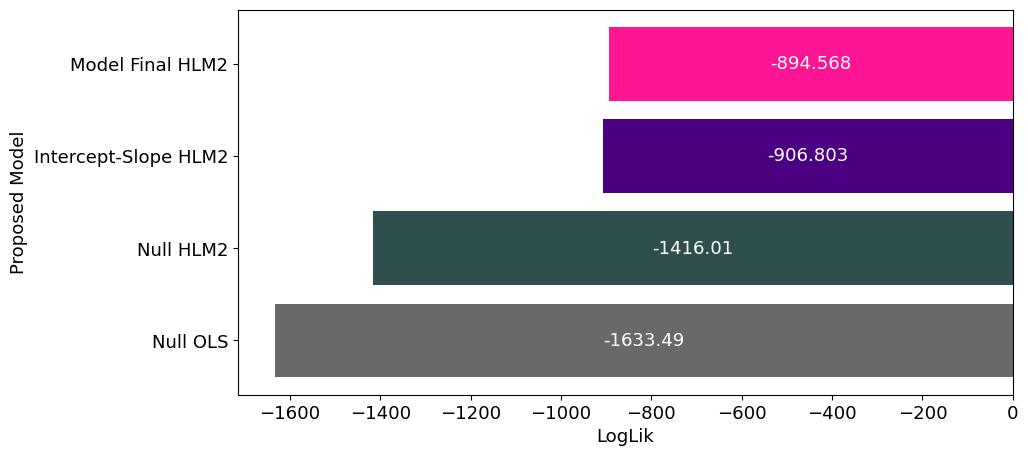

In [34]:
# Plot graph comparing logLiks of models defined up until now:

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM2',
                                 'Intercept-Slope HLM2',
                                 'Model Final HLM2'],
                      'loglik':[ols_null_model.llf,hlm2_null_model.llf,
                                intercept_slope_hlm2_model.llf,
                                intercept_slope_final_hlm2_model.llf]})

fig, ax = plt.subplots(figsize=(10,5))

c = ['dimgray','darkslategray','indigo','deeppink']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [35]:
# LLR test between HLM models intercept_slope_hlm2_model and intercept_slope_final_hlm2_model, in order to confirm 
# their llf difference, statistically.

lrtest([intercept_slope_hlm2_model, intercept_slope_final_hlm2_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 24.47
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [36]:
# Therefore, this last final model, with the W level-2 predictor, does increase our latter intercept + slope (without 
# W) model, with a higher LogLikelihood value and better predictability capacity (smaller residuals).

In [37]:
# Two of the most important differentials of multilevel models are the ni params. These are level-2 adjustment params 
# for the intercept and slope betas, as we've already seen, with different absolute values per each context (school). 
# That's why the model summary shows them as variances, and not as fixed values, differently from the gamas. In our 
# case, school Var (σ²(ν₀ⱼ)) and study_hours Var (σ²(ν₁ⱼ)). As we have 10 j schools at our model, we'll have 10 ν₀ⱼ
# and 10 ν₁ⱼ. So, for each prediction, we have different nis based on which school we're considering at the prediction.

# So, at our final model, we have as ν₀ⱼ and ν₁ⱼ for each j school (context):

random_effects_intercept_slope = pd.DataFrame(intercept_slope_final_hlm2_model.random_effects).T
random_effects_intercept_slope = random_effects_intercept_slope.rename(columns = {'school':'v0j'})
random_effects_intercept_slope = random_effects_intercept_slope.rename(columns = {'study_hours':'v1j'})
random_effects_intercept_slope = random_effects_intercept_slope.reset_index().rename(columns={'index': 'school'})
random_effects_intercept_slope

,school,v0j,v1j
0,1,-0.211364,0.438811
1,2,1.291495,-0.278181
2,3,6.090772,-0.779130
3,4,-5.245506,0.450368
4,5,-1.695358,-0.139678
5,6,3.864292,0.005096
6,7,-8.270892,0.909171
7,8,-1.363471,0.217166
8,9,3.705674,-0.607100
9,10,1.834358,-0.216522


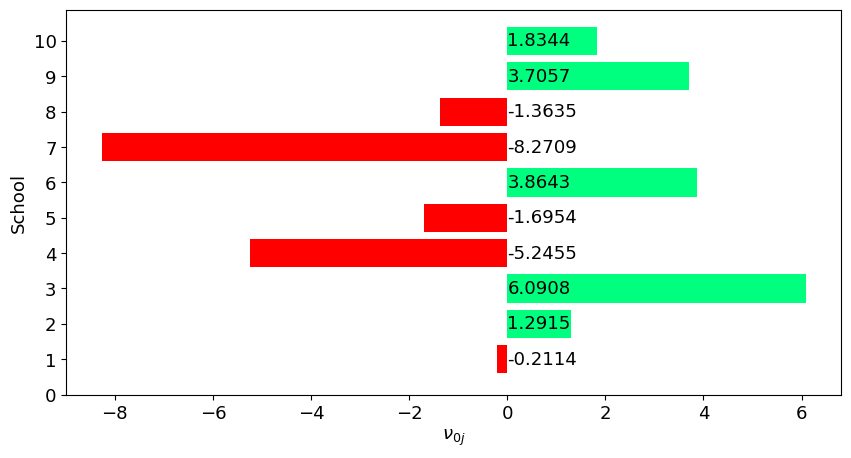

In [38]:
# Plot graph for visualization of ν₀ⱼ random effects per school - σ²(ν₀ⱼ) = 24.345
# Here we may see which particular school already starts with a lower or higher mean of performance regarding its
# own fitted line, compared to others

student_school_df['school'] = student_school_df['school'].astype('int')

colors = ['springgreen' if x>0 else 'red' for x in random_effects_intercept_slope['v0j']]

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(0, point['y'], str(round(point['x'],4)), fontsize=13,
                verticalalignment='center')

plt.figure(figsize=(10,5))
plt.barh(random_effects_intercept_slope['school'], random_effects_intercept_slope['v0j'], color=colors)

label_point(x = random_effects_intercept_slope['v0j'],
            y = random_effects_intercept_slope['school'],
            val = random_effects_intercept_slope['v0j'],
            ax = plt.gca()) 
plt.ylabel('School', fontsize=13)
plt.xlabel(r'$\nu_{0j}$', fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 11, 1))
plt.show()

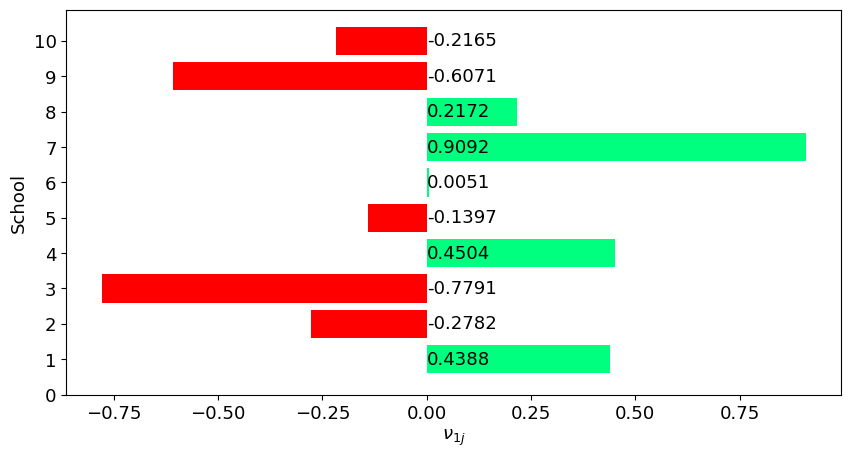

In [39]:
# Plot graph for visualization of ν₁ⱼ random effects per school - σ²(ν₁ⱼ) = 0.305
# Here we may see which particular school already starts with a lower or higher growth slope of performance regarding 
# its own fitted line, compared to others

colors = ['springgreen' if x>0 else 'red' for x in random_effects_intercept_slope['v1j']]

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(0, point['y'], str(round(point['x'],4)), fontsize=13,
                verticalalignment='center')

plt.figure(figsize=(10,5))
plt.barh(random_effects_intercept_slope['school'], random_effects_intercept_slope['v1j'], color=colors)

label_point(x = random_effects_intercept_slope['v1j'],
            y = random_effects_intercept_slope['school'],
            val = random_effects_intercept_slope['v1j'],
            ax = plt.gca()) 
plt.ylabel('School', fontsize=13)
plt.xlabel(r'$\nu_{1j}$', fontsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.yticks(np.arange(0, 11, 1))
plt.show()

In [40]:
student_school_df['school'] = student_school_df['school'].astype('category')

# Visualization of fitted values from the final model per student and per school. fitted.complete is the whole
# final model regression formula result (except residual) and eij is the residual, for each observation of 
# student nested into each respective school.

student_school_df['fitted.complete'] = intercept_slope_final_hlm2_model.fittedvalues
student_school_df['eij'] = intercept_slope_final_hlm2_model.resid
student_school_df

,student,school,performance,study_hours,professor_experience_years,fitted.complete,eij
0,1,1,25.0,11,3.6,26.501371,-1.501371
1,2,1,52.0,23,3.6,50.343641,1.656359
2,3,1,52.0,25,3.6,54.317353,-2.317353
3,4,1,30.0,14,3.6,32.461938,-2.461938
4,5,1,51.0,24,3.6,52.330497,-1.330497
...,...,...,...,...,...,...,...
353,354,10,46.5,28,3.9,46.397262,0.102738
354,355,10,21.0,9,3.9,19.776900,1.223100
355,356,10,42.0,27,3.9,44.996191,-2.996191
356,357,10,14.0,7,3.9,16.974757,-2.974757


In [41]:
# Doing a sample manual prediction for inputs, using the final model:

# Which scholar performance is predicted for a given student from school id = 1, knowing that he studies 11h/week and
# that the school offers an average of professor experience hours of about 3.6 years ?

# VERY IMPORTANT !!!! At the used API, the predict() function only considers the fixed effect, so we gotta calculate
# a partial value for the dependent variable, with the predict(), and later add manually the rest of the 
# fitted.complete formula, that is, the parts of the final model regression expression with the ni params (ν₀ⱼ and 
# ν₁ⱼ) - see the full expression at the explanations and formulas images above. So we calculate the fixed part of
# the expression and only then the complete result, summing up the random effects on the intercept and slope.

fixed_performance_result = intercept_slope_final_hlm2_model.predict(pd.DataFrame({'study_hours':[11],
                                                         'professor_experience_years':[3.6],
                                                         'school':['1']}))
fixed_performance_result

# adding random effects to the fixed effects just calculated (adding the random part of the regression formula):

complete_performance_result = fixed_performance_result + random_effects_intercept_slope['v0j'][0] +\
    random_effects_intercept_slope['v1j'][0]*11

print(f"Performance of a student from school id = 1, who studies 11h/week and whose school offers an average of professor experience of about 3.6 years is {complete_performance_result[0]:.8}")

# This is exactly the performance of student 1, calculated automatically above.

Performance of a student from school id = 1, who studies 11h/week and whose school offers an average of professor experience of about 3.6 years is 26.501371


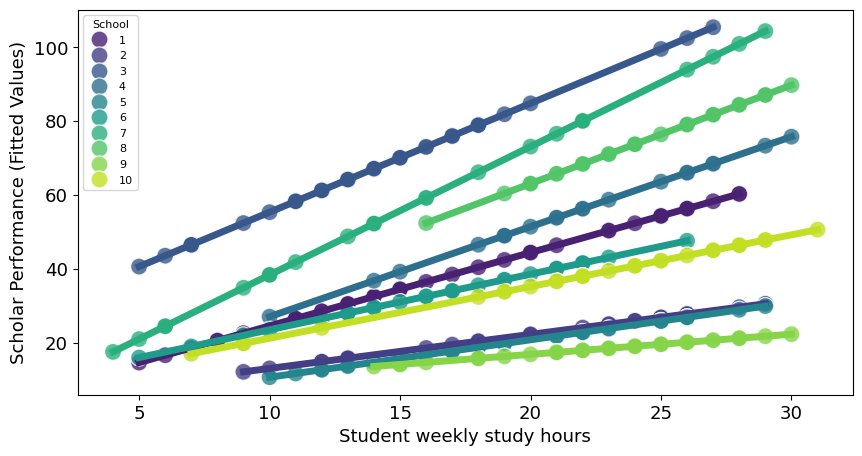

In [42]:
# Plot graph with predicted values for scholar performance regressed on study_hours variable at the 
# intercept_slope_final_hlm2_model

palette = sns.color_palette('viridis',
                            len(student_school_df['school'].unique()))

plt.figure(figsize=(10,5))
sns.scatterplot(data=student_school_df, x='study_hours', y='fitted.complete',
                hue='school', palette=palette, s=150, alpha=0.8, edgecolor='w')

for school in student_school_df['school'].cat.categories:
    subset = student_school_df[student_school_df['school'] == school]
    sns.regplot(data=subset, x='study_hours', y='fitted.complete',
                scatter=False, ci=False,
                line_kws={"color": palette[student_school_df['school'].cat.categories.get_loc(school)],
                          'linewidth': 5})

plt.xlabel('Student weekly study hours', fontsize=13)
plt.ylabel('Scholar Performance (Fitted Values)', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(title='School', title_fontsize='8', fontsize='8', loc='upper left')
plt.show()

In [43]:
# comparison of Multilevel Regression Models (GLMM / HLM) with Traditional Linear Regression Models (GLM / OLS)

# estimating an OLS model for comparison

ols_model = sm.OLS.from_formula('performance ~ study_hours + professor_experience_years',
                                 student_school_df).fit()

ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     827.1
Date:                Mon, 04 May 2026   Prob (F-statistic):          2.38e-134
Time:                        10:09:56   Log-Likelihood:                -1323.2
No. Observations:                 358   AIC:                             2652.
Df Residuals:                     355   BIC:                             2664.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    -23.3983      1.989    -11.761      0.000     -27.311     -19.486
study_hours                    1.9100      0.084     22.758      0.000       1.745       2.075
professor_experience_years     5.5545      0.145     38.268      0.000       5.269       5.840
==============================================================================
Omnibus:                        8.245   Durbin-Watson:                   0.719
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                5.073
Skew:                          -0.109   Prob(JB):                       0.0791
Kurtosis:                       2.459   Cond. No.                         79.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

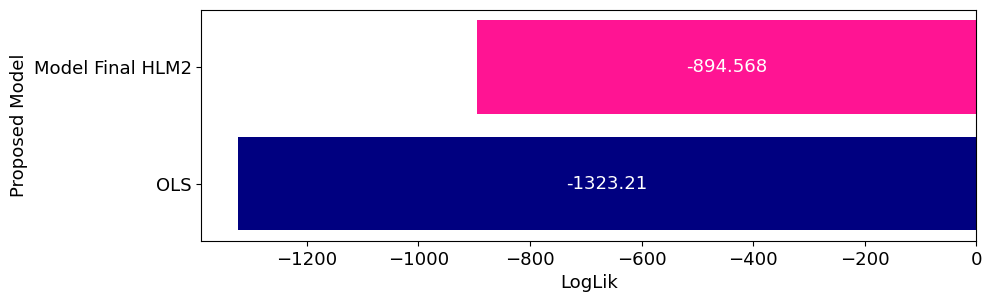

In [44]:
# Plot graph for visual comparison of logLiks of the final GLMM HML model above with the GLM OLS model

llf_df = pd.DataFrame({'model': ['OLS', 'Model Final HLM2'],
                       'loglik': [ols_model.llf, intercept_slope_final_hlm2_model.llf]})

fig, ax = plt.subplots(figsize=(10, 3))

colors = ['navy', 'deeppink']

ax1 = ax.barh(llf_df.model, llf_df.loglik, color=colors)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

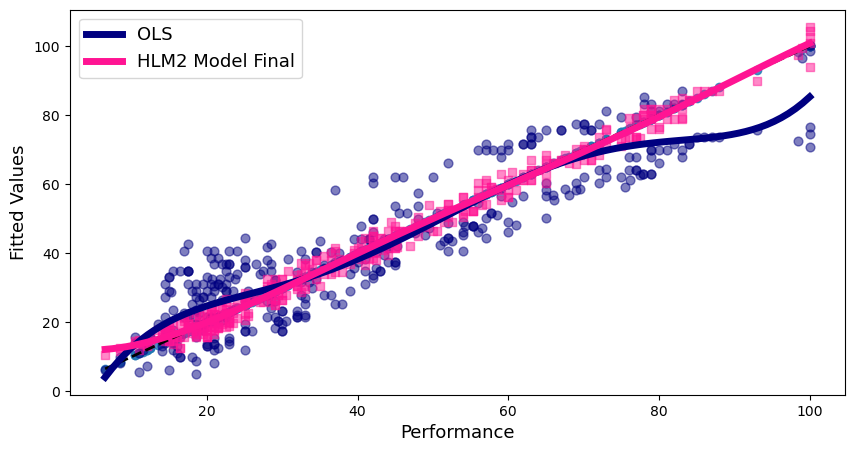

In [45]:
# Plot graph for comparing fitted values of the final GLMM HML model above with the GLM OLS model

plt.figure(figsize=(10,5))
sns.regplot(x=student_school_df['performance'],
            y=student_school_df['performance'],
            ci=None,
            line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})
sns.regplot(x=student_school_df['performance'],
            y=ols_model.fittedvalues,
            ci=None, marker='o', order=5,
            scatter_kws={'color':'navy', 's':40, 'alpha':0.5},
            line_kws={'color':'navy', 'linewidth':5,
                      'label':'OLS'})
sns.regplot(x=student_school_df['performance'],
            y=student_school_df['fitted.complete'],
            ci=None, marker='s', order=5,
            scatter_kws={'color':'deeppink', 's':40, 'alpha':0.5},
            line_kws={'color':'deeppink', 'linewidth':5,
                      'label':'HLM2 Model Final'})
plt.xlabel('Performance', fontsize=13)
plt.ylabel('Fitted Values', fontsize=13)
plt.legend(fontsize=13)
plt.show()

In [46]:
# trying another OLS model, with school qualitative variable dummized into 9 dummies, for later comparing its LogLik 
# with the LogLik of the GLMM final model above, and do a final verification of GLMM models superiority in multilayered
# data cases, as this one

student_school_with_dummies_df = pd.get_dummies(student_school_df, columns=['school'],
                                         dtype=int,
                                         drop_first=True)

student_school_with_dummies_df

,student,performance,study_hours,professor_experience_years,fitted.complete,eij,school_2,school_3,school_4,school_5,school_6,school_7,school_8,school_9,school_10
0,1,25.0,11,3.6,26.501371,-1.501371,0,0,0,0,0,0,0,0,0
1,2,52.0,23,3.6,50.343641,1.656359,0,0,0,0,0,0,0,0,0
2,3,52.0,25,3.6,54.317353,-2.317353,0,0,0,0,0,0,0,0,0
3,4,30.0,14,3.6,32.461938,-2.461938,0,0,0,0,0,0,0,0,0
4,5,51.0,24,3.6,52.330497,-1.330497,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,354,46.5,28,3.9,46.397262,0.102738,0,0,0,0,0,0,0,0,1
354,355,21.0,9,3.9,19.776900,1.223100,0,0,0,0,0,0,0,0,1
355,356,42.0,27,3.9,44.996191,-2.996191,0,0,0,0,0,0,0,0,1
356,357,14.0,7,3.9,16.974757,-2.974757,0,0,0,0,0,0,0,0,1


In [47]:
# estimating the Multiple Linear Regression OLS Model with n-1 dummies

column_list = list(student_school_with_dummies_df.drop(columns=['student',
                                                           'performance',
                                                           'fitted.complete',
                                                           'eij']).columns)

formula_dummies_model = ' + '.join(column_list)
formula_dummies_model = "performance ~ " + formula_dummies_model
print("Formula: ",formula_dummies_model)

Formula:  performance ~ study_hours + professor_experience_years + school_2 + school_3 + school_4 + school_5 + school_6 + school_7 + school_8 + school_9 + school_10


In [48]:
# actually estimating the Multiple Linear Regression OLS Model with n-1 dummies (with the formula expression above)

ols_dummies_model = sm.OLS.from_formula(formula_dummies_model,
                                         student_school_with_dummies_df).fit()

ols_dummies_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            performance   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     575.7
Date:                Mon, 04 May 2026   Prob (F-statistic):          2.81e-209
Time:                        10:09:56   Log-Likelihood:                -1120.2
No. Observations:                 358   AIC:                             2262.
Df Residuals:                     347   BIC:                             2305.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                    -11.0528      1.352     -8.175      0.000     -13.712      -8.394
study_hours                    1.9713      0.056     35.063      0.000       1.861       2.082
professor_experience_years     4.4516      0.096     46.582      0.000       4.264       4.640
school_2                     -14.6664      1.452    -10.101      0.000     -17.522     -11.811
school_3                      -7.2914      0.685    -10.651      0.000      -8.638      -5.945
school_4                      -0.7854      1.443     -0.544      0.587      -3.624       2.053
school_5                     -14.8095      1.238    -11.967      0.000     -17.244     -12.375
school_6                      -3.3658      1.321     -2.548      0.011      -5.964      -0.768
school_7                       2.3462      1.115      2.103      0.036       0.152       4.540
school_8                       4.5433      1.130      4.021      0.000       2.321       6.766
school_9                     -24.6820      1.323    -18.657      0.000     -27.284     -22.080
school_10                    -11.9232      1.310     -9.099      0.000     -14.501      -9.346
==============================================================================
Omnibus:                       14.171   Durbin-Watson:                   2.091
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               32.665
Skew:                           0.002   Prob(JB):                     8.07e-08
Kurtosis:                       4.480   Cond. No.                     6.88e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.21e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [49]:
# running stepwise method for the ols_dummies_model model above

ols_dummies_step_model = stepwise(ols_dummies_model, pvalue_limit=0.05)

Regression type: OLS 

Estimating model...: 
 performance ~ Q('study_hours') + Q('professor_experience_years') + Q('school_2') + Q('school_3') + Q('school_4') + Q('school_5') + Q('school_6') + Q('school_7') + Q('school_8') + Q('school_9') + Q('school_10')

 Discarding atribute "Q('school_4')" with p-value equal to 0.5866607155055688 

Estimating model...: 
 performance ~ Q('study_hours') + Q('professor_experience_years') + Q('school_2') + Q('school_3') + Q('school_5') + Q('school_6') + Q('school_7') + Q('school_8') + Q('school_9') + Q('school_10')

 Discarding atribute "Q('school_3')" with p-value equal to 0.638511306980294 

Estimating model...: 
 performance ~ Q('study_hours') + Q('professor_experience_years') + Q('school_2') + Q('school_5') + Q('school_6') + Q('school_7') + Q('school_8') + Q('school_9') + Q('school_10')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('school_4')", 'p-value': np.float64(0.5866607155055688)}

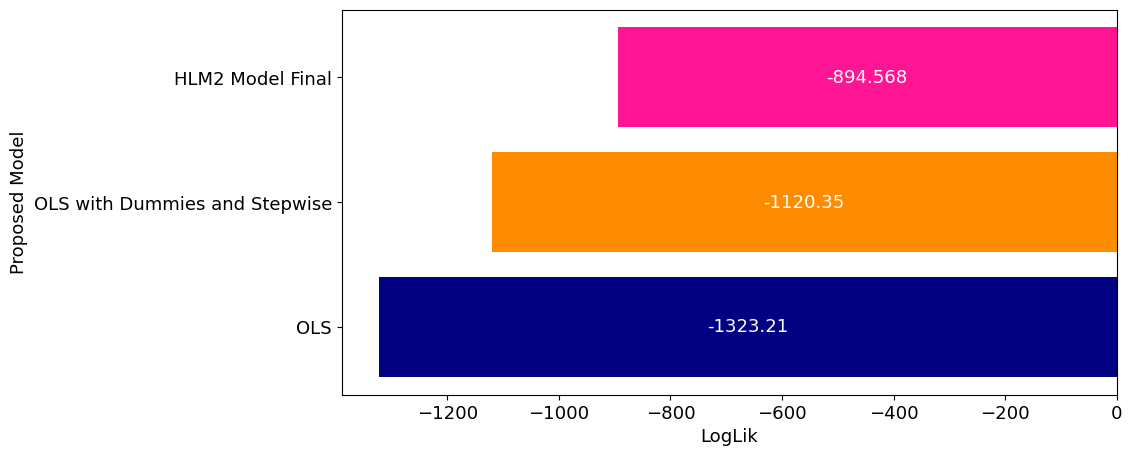

In [50]:
# Plot graph for comparing LogLiks of the GLMM final model above with the OLS models (with and without Dummies)

llf_df = pd.DataFrame({'model':['OLS',
                                 'OLS with Dummies and Stepwise',
                                 'HLM2 Model Final'],
                      'loglik':[ols_model.llf,
                                ols_dummies_step_model.llf,
                                intercept_slope_final_hlm2_model.llf]})

fig, ax = plt.subplots(figsize=(10,5))

c = ['navy','darkorange','deeppink']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [51]:
# Comparison between models' parameters

summary_col([ols_dummies_step_model, intercept_slope_final_hlm2_model],
            model_names=["OLS with Dummies and Stepwise","HLM2 Model Final"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs)),
                'Log-lik':lambda x: "{:.2f}".format(x.llf)
                })

,OLS with Dummies and Stepwise,HLM2 Model Final
Intercept,-8.1412***,-0.8496
,(1.4895),(2.9987)
Q('study_hours'),1.9774***,
,(0.0547),
Q('professor_experience_years'),3.6635***,
,(0.1203),
Q('school_2'),-16.0388***,
,(1.4151),
Q('school_5'),-16.3362***,
,(1.1957),


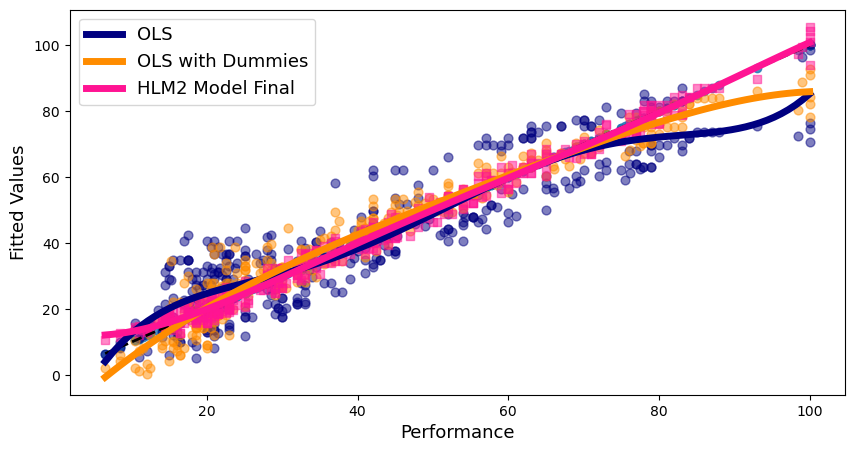

In [52]:
# Plot graph comparing fitted values at each model

plt.figure(figsize=(10,5))
sns.regplot(x=student_school_df['performance'],
            y=student_school_df['performance'],
            ci=None,
            line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})
sns.regplot(x=student_school_df['performance'],
            y=ols_model.fittedvalues,
            ci=None, marker='o', order=5,
            scatter_kws={'color':'navy', 's':40, 'alpha':0.5},
            line_kws={'color':'navy', 'linewidth':5,
                      'label':'OLS'})
sns.regplot(x=student_school_df['performance'],
            y=ols_dummies_step_model.fittedvalues,
            ci=None, marker='o', order=5,
            scatter_kws={'color':'darkorange', 's':40, 'alpha':0.5},
            line_kws={'color':'darkorange', 'linewidth':5,
                      'label':'OLS with Dummies'})
sns.regplot(x=student_school_df['performance'],
            y=student_school_df['fitted.complete'],
            ci=None, marker='s', order=5,
            scatter_kws={'color':'deeppink', 's':40, 'alpha':0.5},
            line_kws={'color':'deeppink', 'linewidth':5,
                      'label':'HLM2 Model Final'})
plt.xlabel('Performance', fontsize=13)
plt.ylabel('Fitted Values', fontsize=13)
plt.legend(fontsize=13)
plt.show()

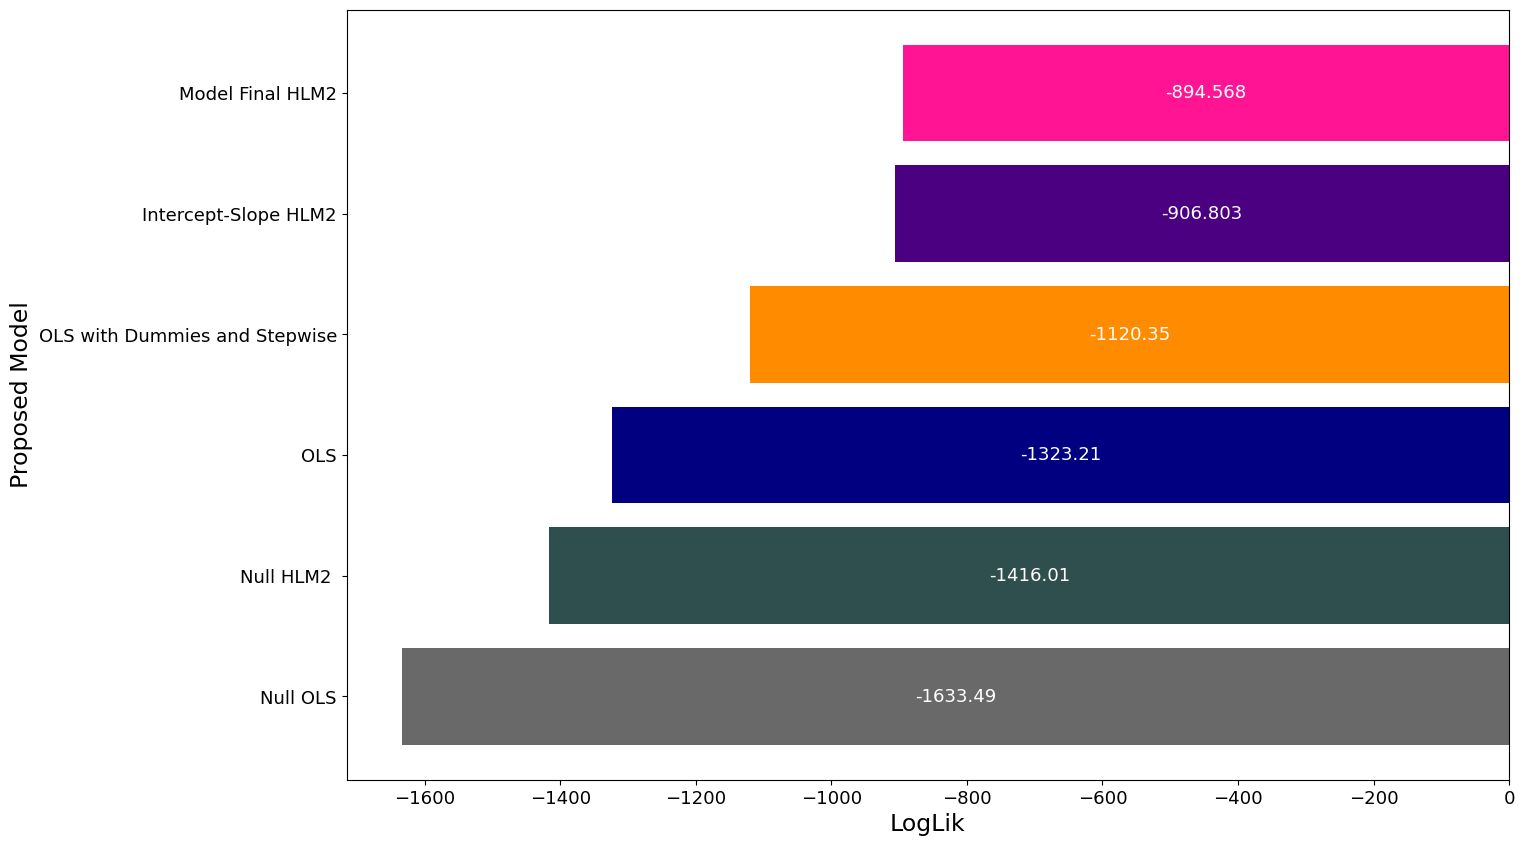

In [53]:
# Plot graph for comparing LogLiks of all models at this project

llf_df = pd.DataFrame({'model':['Null OLS','Null HLM2 ','OLS',
                                 'OLS with Dummies and Stepwise',
                                 'Intercept-Slope HLM2',
                                 'Model Final HLM2'],
                      'loglik':[ols_null_model.llf,hlm2_null_model.llf,
                                ols_model.llf,
                                ols_dummies_step_model.llf,
                                intercept_slope_hlm2_model.llf,
                                intercept_slope_final_hlm2_model.llf]})

fig, ax = plt.subplots(figsize=(15,10))

c = ['dimgray','darkslategray','navy','darkorange','indigo','deeppink']

ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=17)
ax.set_xlabel("LogLik", fontsize=17)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [54]:
# definitely, the best model for this GLMM HLM Multilevel Regression Analysis use case is the 
# intercept_slope_final_hlm2_model, which has statistically the highest (less negative) LogLikelihood compared to all 
# others, specially when compared to OLS traditional models, with or without dummyzation of the schools as qualitative 
# variables. Again, this is due to the exclusive capacity of such models to modelate the variance of each observation
# level-2 random effects on both the intercept as on the slope of each regression curve, instead of assuming one single
# linear regression for all observations, without considering the stratification of such data into level-2 specific
# groups (clusters), each with its own regression context random effects.